# Pipeline klasyfikacji obrazów

Zbiór to zdjęcia śmieci z przypisanymi etykietami:
- cardboard
- glass
- metal
- paper
- plastic
- trash

## Preprocessing
Za nim co kolwiek zrobimy z danymi, powinniśmy na nie spojrzeć. (zaufajcie zrobiłem to)

In [37]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns
import matplotlib.pyplot as plt

Nie ma pustych wartości, liczba klas jest równa liczbie zdjęć, więc nie ma sytuacji gdzie zdjęcie nie ma przypisanej klasy lub jest przypisane do kilku klas


In [39]:
batch_size = 32

#prawdziwe wartości
# img_height = 384
# img_width = 512

#skalowane wartości (szybkie)
# img_height = 128
# img_width = 128

# dokładniejsze wartości (też szybkie ale dokładniejsze)
img_height = 256
img_width = 256


In [40]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

data_dir = './train/'

class_names = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
])

num_classes = len(class_names)

file_paths = []
labels = []

for idx, class_name in enumerate(class_names):
    class_dir = os.path.join(data_dir, class_name)
    
    for fname in os.listdir(class_dir):
        file_paths.append(os.path.join(class_dir, fname))
        labels.append(idx)

file_paths = np.array(file_paths)
labels = np.array(labels, dtype=np.int32)


X_train, X_temp, y_train, y_temp = train_test_split(
    file_paths, labels, test_size=0.3, stratify=labels, random_state=67
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.33, stratify=y_temp, random_state=67
)

In [41]:
def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [img_height, img_width])
    return img, label

def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    if training:
        ds = ds.cache()
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(X_train, y_train, training=True)
val_ds = make_ds(X_val, y_val)
test_ds = make_ds(X_test, y_test)

print(np.unique(y_train, return_counts=True))
print(np.unique(y_val, return_counts=True))
print(np.unique(y_test, return_counts=True))


(array([0, 1, 2, 3, 4, 5], dtype=int32), array([282, 350, 286, 416, 336,  96]))
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([ 81, 101,  82, 119,  96,  28]))
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([40, 50, 41, 59, 48, 13]))


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

data_augmentation = Sequential([
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1)
])

model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    # data_augmentation(),
    
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-5)



class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weight_dict
)

Epoch 1/40


c:\Users\lukas\OneDrive\Pulpit\projekty\projekt_smieci\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 427ms/step - accuracy: 0.2860 - loss: 1.7355 - val_accuracy: 0.2919 - val_loss: 1.6669 - learning_rate: 0.0010
Epoch 2/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 386ms/step - accuracy: 0.3709 - loss: 1.5472 - val_accuracy: 0.3767 - val_loss: 1.5303 - learning_rate: 0.0010
Epoch 3/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 389ms/step - accuracy: 0.3805 - loss: 1.4768 - val_accuracy: 0.3866 - val_loss: 1.4680 - learning_rate: 0.0010
Epoch 4/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.4009 - loss: 1.4056 - val_accuracy: 0.3688 - val_loss: 1.4550 - learning_rate: 0.0010
Epoch 5/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 378ms/step - accuracy: 0.4139 - loss: 1.3698 - val_accuracy: 0.4260 - val_loss: 1.3956 - learning_rate: 0.0010
Epoch 6/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 368ms/step - accuracy: 0.4298 - loss: 1.3363 - val_accuracy: 0.4320 - val_loss: 1.3300 - learning_rate: 0.0010
Epoch 7/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 378ms/step - accuracy: 0.4513 - loss: 1.2883 - val_

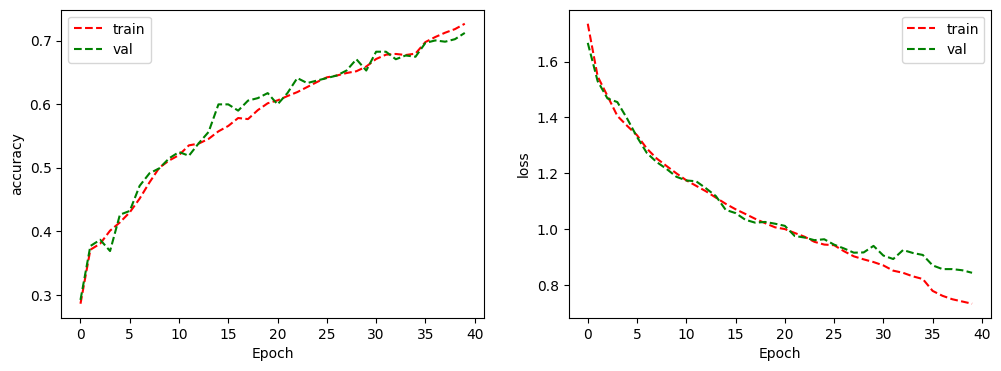

In [43]:
def draw_curves(history):
    plt.figure(figsize=(12,4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], "r--", label='train')
    plt.plot(history.history['val_accuracy'], "g--", label='val')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], "r--", label='train')
    plt.plot(history.history['val_loss'], "g--", label='val')
    plt.ylabel('loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.show()

draw_curves(history)

# Ocena predykcji

In [44]:
import numpy as np

logits = model.predict(test_ds)
probs = tf.nn.softmax(logits)
y_pred = np.argmax(probs, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step


In [45]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.7171314741035857


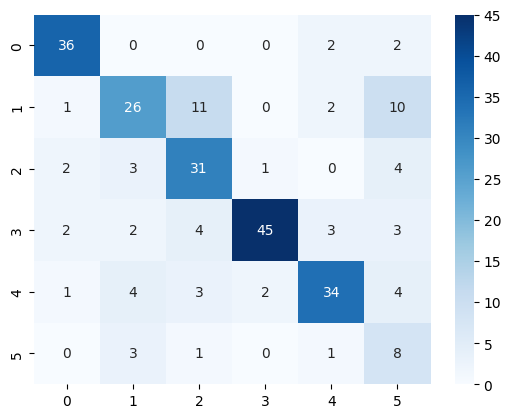

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

# Podsumowanie.
Accuracy na zbiorze treningowym, walidacyjnym, testowym są całkiem sobie bliskie, pokusił bym się o stwierdzenie, że model  nie jest przetrenowany
Można poprawić jakość modelu przez analizę macierzy pomyłem (sprawdzić co najczęściej myli się z czym)